# Lab3 ResNet KWS

Обучение ResNet-модели для KWS (`one`-`nine`, `silence`, `unknown`) и оценка на test.

In [7]:
import random
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchaudio
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

TARGET_DIGITS = ["one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
ALL_TARGETS = TARGET_DIGITS + ["silence", "unknown"]

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-3

import os
from tqdm.auto import tqdm

Device: cuda


In [8]:
train_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="training", download=True)
val_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="validation", download=True)
test_ds = torchaudio.datasets.SPEECHCOMMANDS(root=str(DATA_DIR), subset="testing", download=True)

print(f"train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")


def resolve_path(dataset, rel_path):
    p = Path(rel_path)
    candidates = [p, Path(dataset._archive) / p, Path.cwd() / p]
    for c in candidates:
        if c.exists():
            return str(c)
    return None


def collect_rows(dataset, labels):
    rows = []
    counts = {l: 0 for l in labels}
    for rel_path in dataset._walker:
        label = Path(rel_path).parent.name
        if label not in labels:
            continue
        rp = resolve_path(dataset, rel_path)
        if rp is None:
            continue
        rows.append((rp, label))
        counts[label] += 1
    return rows, counts


def collect_unknown(dataset, known_labels, target_count, seed=42):
    rng = np.random.default_rng(seed)
    by_label = {}
    for rel_path in dataset._walker:
        label = Path(rel_path).parent.name
        if label in known_labels or label == "_background_noise_":
            continue
        rp = resolve_path(dataset, rel_path)
        if rp is None:
            continue
        by_label.setdefault(label, []).append((rp, "unknown"))

    labels = sorted(by_label)
    per_class = max(1, target_count // max(1, len(labels)))
    rem = target_count % max(1, len(labels))
    out = []
    for i, lbl in enumerate(labels):
        items = by_label[lbl]
        take = per_class + (1 if i < rem else 0)
        if len(items) <= take:
            out.extend(items)
        else:
            idx = rng.choice(len(items), size=take, replace=False)
            out.extend([items[j] for j in idx])
    return out


def make_silence(dataset, count, seed=42):
    rng = np.random.default_rng(seed)
    n_dir = DATA_DIR / "SpeechCommands" / "speech_commands_v0.02" / "_background_noise_"
    files = sorted(n_dir.glob("*.wav"))
    out = []
    if not files:
        return [(None, "silence", 0.0, 1.0) for _ in range(count)]

    for _ in range(count):
        f = files[rng.integers(0, len(files))]
        y, sr = librosa.load(str(f), sr=None, mono=True)
        dur = len(y) / sr
        mx = max(0.0, dur - 1.0)
        off = float(rng.uniform(0.0, mx)) if mx > 0 else 0.0
        out.append((str(f), "silence", off, 1.0))
    return out

train=84843, val=9981, test=11005


In [9]:
known = TARGET_DIGITS

train_rows_base, train_count_base = collect_rows(train_ds, known)
val_rows_base, val_count_base = collect_rows(val_ds, known)
test_rows_base, test_count_base = collect_rows(test_ds, known)

train_sil = make_silence(train_ds, max(train_count_base.values()), seed=SEED)
val_sil = make_silence(val_ds, max(val_count_base.values()), seed=SEED + 1)
test_sil = make_silence(test_ds, max(test_count_base.values()), seed=SEED + 2)

train_unk = collect_unknown(train_ds, known, max(train_count_base.values()), seed=SEED + 10)
val_unk = collect_unknown(val_ds, known, max(val_count_base.values()), seed=SEED + 11)
test_unk = collect_unknown(test_ds, known, max(test_count_base.values()), seed=SEED + 12)

train_rows = train_rows_base + train_sil + train_unk
val_rows = val_rows_base + val_sil + val_unk
test_rows = test_rows_base + test_sil + test_unk

print("train rows:", len(train_rows))
print("val rows:", len(val_rows))
print("test rows:", len(test_rows))

train rows: 34388
val rows: 4033
test rows: 4579


In [10]:
import os
from tqdm.auto import tqdm

# Классы и загрузка WAV (согласовано со сплитами train/val/test)
labels_cnn = sorted({r[1] for r in train_rows + val_rows + test_rows})
label_to_idx = {l: i for i, l in enumerate(labels_cnn)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
labels = labels_cnn  # для len(labels) и classification_report

def row_to_audio(row):
    if len(row) == 2:
        audio_path, _ = row
        y, sr = librosa.load(str(audio_path), sr=None, mono=True)
        return y, sr
    audio_path, _, offset_sec, duration_sec = row
    if audio_path is None:
        return np.zeros(16000, dtype=np.float32), 16000
    y, sr = librosa.load(
        str(audio_path), sr=None, mono=True, offset=offset_sec, duration=duration_sec
    )
    return y, sr

# Настройка трансформации для GPU
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=512,
    hop_length=160,
    n_mels=128
).to(DEVICE)

def get_logmel_batch(audio_batch):
    # audio_batch: [B, 1, 16000]
    with torch.no_grad():
        mels = mel_transform(audio_batch)
        log_mels = torch.log(mels + 1e-6)
        # Нормализация по батчу
        mean = log_mels.mean(dim=(1, 2, 3), keepdim=True)
        std = log_mels.std(dim=(1, 2, 3), keepdim=True)
        return (log_mels - mean) / (std + 1e-6)

class FastKwsDataset(Dataset):
    def __init__(self, rows, label_to_idx):
        self.rows = rows
        self.label_to_idx = label_to_idx
        print(f"Pre-loading {len(rows)} samples into RAM...")
        self.data = []
        for row in tqdm(rows):
            y, sr = row_to_audio(row)
            if sr != 16000:
                y = librosa.resample(y, orig_sr=sr, target_sr=16000)
            if len(y) < 16000:
                y = np.pad(y, (0, 16000 - len(y)))
            else:
                y = y[:16000]
            label = row[1]
            self.data.append((torch.from_numpy(y).float(), label_to_idx[label]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# Увеличиваем Batch Size для лучшей утилизации GPU
BATCH_SIZE = 128

train_dataset = FastKwsDataset(train_rows, label_to_idx)
val_dataset = FastKwsDataset(val_rows, label_to_idx)
test_dataset = FastKwsDataset(test_rows, label_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Pre-loading 34388 samples into RAM...


100%|██████████| 34388/34388 [00:31<00:00, 1088.37it/s]


Pre-loading 4033 samples into RAM...


100%|██████████| 4033/4033 [00:03<00:00, 1026.60it/s]


Pre-loading 4579 samples into RAM...


100%|██████████| 4579/4579 [00:04<00:00, 1030.01it/s]


In [11]:
import time
from sklearn.metrics import accuracy_score

class ResNetKWS(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        # x: [B, 16000] входящие сырые данные на DEVICE
        x = x.unsqueeze(1)
        x = get_logmel_batch(x)
        return self.backbone(x)

def run_epoch(model, loader, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train(is_train)
    loss_fn = nn.CrossEntropyLoss()
    total_loss, y_true, y_pred = 0.0, [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = loss_fn(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1_m = f1_score(y_true, y_pred, average="macro")
    f1_w = f1_score(y_true, y_pred, average="weighted")
    return avg_loss, acc, f1_m, f1_w, y_true, y_pred

model = ResNetKWS(num_classes=len(labels)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_state = None
best_val_f1 = -1.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.perf_counter()
    tr_loss, tr_acc, tr_f1m, _, _, _ = run_epoch(model, train_loader, optimizer, desc=f"Train {epoch}")
    va_loss, va_acc, va_f1m, va_f1w, _, _ = run_epoch(model, val_loader, desc=f"Val {epoch}")
    dur = time.perf_counter() - t0

    if va_f1m > best_val_f1:
        best_val_f1 = va_f1m
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch} | {dur:.1f}s | Val Acc: {va_acc:.4f} | Val F1: {va_f1m:.4f}")

if best_state:
    model.load_state_dict(best_state)

Epoch 1 | 16.9s | Val Acc: 0.9164 | Val F1: 0.9195


Epoch 2 | 19.0s | Val Acc: 0.9425 | Val F1: 0.9446


Epoch 3 | 25.0s | Val Acc: 0.9524 | Val F1: 0.9525


Epoch 4 | 172.0s | Val Acc: 0.9459 | Val F1: 0.9459


Epoch 5 | 188.0s | Val Acc: 0.9574 | Val F1: 0.9577


Validation acc: 0.9574 | F1_macro: 0.9577 | F1_w: 0.9576
              precision    recall  f1-score   support

       eight     0.9826    0.9769    0.9797       346
        five     0.9033    0.9673    0.9342       367
        four     0.9628    0.9705    0.9666       373
        nine     0.9823    0.9354    0.9583       356
         one     0.9939    0.9345    0.9633       351
       seven     0.9720    0.9871    0.9795       387
     silence     0.9974    0.9974    0.9974       387
         six     0.9946    0.9762    0.9853       378
       three     0.9848    0.9101    0.9460       356
         two     0.9241    0.9884    0.9552       345
     unknown     0.8532    0.8863    0.8695       387

    accuracy                         0.9574      4033
   macro avg     0.9592    0.9573    0.9577      4033
weighted avg     0.9588    0.9574    0.9576      4033




Test acc: 0.9559 | F1_macro: 0.9563 | F1_w: 0.9558
              precision    recall  f1-score   support

       eight     0.9659    0.9730    0.9695       408
        five     0.9160    0.9798    0.9468       445
        four     0.9673    0.9625    0.9649       400
        nine     0.9677    0.9534    0.9605       408
         one     0.9947    0.9398    0.9665       399
       seven     0.9504    0.9901    0.9698       406
     silence     1.0000    0.9978    0.9989       445
         six     0.9896    0.9695    0.9795       394
       three     0.9864    0.8938    0.9378       405
         two     0.9194    0.9953    0.9558       424
     unknown     0.8784    0.8607    0.8695       445

    accuracy                         0.9559      4579
   macro avg     0.9578    0.9560    0.9563      4579
weighted avg     0.9568    0.9559    0.9558      4579



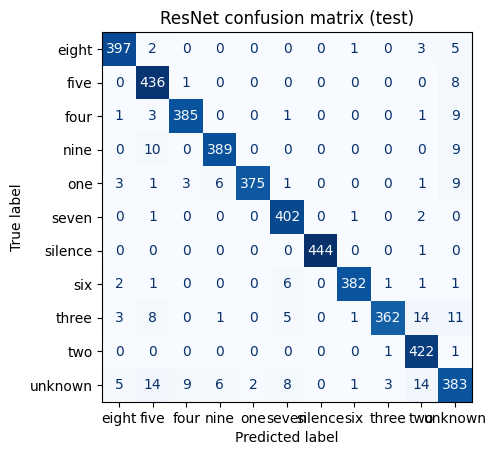

In [12]:
_, val_acc, val_f1, val_f1w, yv_true_idx, yv_pred_idx = run_epoch(
    model, val_loader, optimizer=None, desc="val (best weights)"
)
yv_true = np.array([idx_to_label[i] for i in yv_true_idx])
yv_pred = np.array([idx_to_label[i] for i in yv_pred_idx])

print("Validation acc:", round(val_acc, 4), "| F1_macro:", round(val_f1, 4), "| F1_w:", round(val_f1w, 4))
print(classification_report(yv_true, yv_pred, labels=labels, digits=4))

_, test_acc, test_f1, test_f1w, yt_true_idx, yt_pred_idx = run_epoch(
    model, test_loader, optimizer=None, desc="test"
)
yt_true = np.array([idx_to_label[i] for i in yt_true_idx])
yt_pred = np.array([idx_to_label[i] for i in yt_pred_idx])

print("\nTest acc:", round(test_acc, 4), "| F1_macro:", round(test_f1, 4), "| F1_w:", round(test_f1w, 4))
print(classification_report(yt_true, yt_pred, labels=labels, digits=4))

cm = confusion_matrix(yt_true, yt_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap="Blues", colorbar=False)
plt.title("ResNet confusion matrix (test)")
plt.show()

In [13]:
# Сохранить лучшие веса ResNet (после обучения: model уже с load_state_dict(best_state))
from pathlib import Path

ART = Path("artifacts")
ART.mkdir(parents=True, exist_ok=True)
out = ART / "kws_resnet.pt"
torch.save(
    {
        "state_dict": model.state_dict(),
        "labels": list(labels_cnn),
        "arch": "resnet18_kws",
        "n_mels": 128,
        "n_fft": 512,
        "hop_length": 160,
        "sample_rate": 16000,
    },
    out,
)
print("Saved:", out.resolve())


Saved: /home/raul/code/mtuci-piis/artifacts/kws_resnet.pt
